# End-of-Term Survey: Deep Dive into Student Experience Patterns

This notebook analyzes **116 end-of-term survey responses** from INFO 330 students who experienced AI-enhanced formative feedback throughout the course.

Unlike the mid-term survey (which captured immediate reactions to Milestone 2), the end-of-term survey asks broader, more reflective questions:

| Question | Focus |
|----------|-------|
| **Q1** | Name two courses where AI feedback might work |
| **Q2** | Give an example assignment per course |
| **Q3** | What assurances would you need from the instructor? |
| **Q4** | Did INFO 330's AI feedback shift your view of your *own* AI use? |
| **Q5** | Did the in-lecture AI demo change your perception? |

The core question this notebook addresses: **did the intervention produce durable, generalizable belief change — not just momentary satisfaction?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from textwrap import fill
from collections import Counter
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
warnings.filterwarnings("ignore")

In [2]:
df_raw = pd.read_csv("../end-of-term-survey.csv")
print(f"Loaded {len(df_raw)} responses with {df_raw.shape[1]} columns.")

df = df_raw.copy()
df.columns = [
    "timestamp", "courses", "ai_assignments", "assurances",
    "own_ai_shift", "demo_effect", "follow_up"
]
df.head(3)

Loaded 116 responses with 7 columns.


,timestamp,courses,ai_assignments,assurances,own_ai_shift,demo_effect,follow_up
0,3/12/2026 23:16:10,info 442 info 478,"- for info 442, i would ask AI if my css match...","if ai is used, explain how you used it and wha...",Did the fact that your instructor in INFO 330 ...,i wasnt there,Yes
1,3/12/2026 23:25:36,"INFO 201, CSE 373",For INFO 201 it could provide suggestions on w...,Yes.,No it did not shift my view of my own use of A...,No it did not.,No
2,3/12/2026 23:59:59,Web Programming (CSE 154); Data and Society (S...,CSE 154: Could be used to create a jest checke...,"For either class, I would want to know that th...",I dont think it necessarily changed my thought...,No it was somewhat anticipated the way it work...,Yes


## 1. Response Overview

116 students completed the end-of-term survey (vs. 95 for the mid-term). All questions are open-ended — this survey captures reflection and generalization rather than immediate reactions.

The follow-up interview consent rate here is a natural baseline for engagement depth.

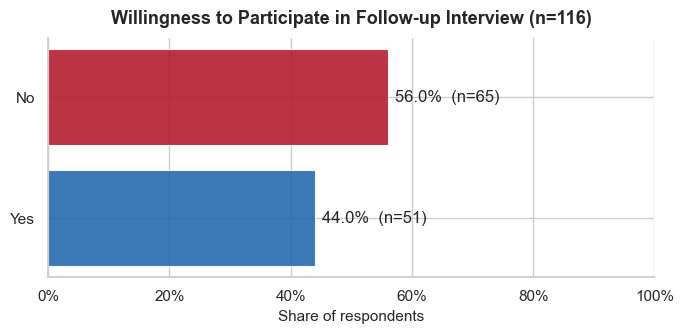


Note: mid-term follow-up willingness was 25.3% (24/95).
End-of-term: 44.0% (51/116)


In [3]:
follow_up_counts = df["follow_up"].value_counts()
n_total = len(df)

fig, ax = plt.subplots(figsize=(7, 3.5))

color_map = {"Yes": "#2166AC", "No": "#B2182B"}
bar_colors = [color_map.get(k, "#888888") for k in follow_up_counts.index]

ax.barh(follow_up_counts.index[::-1],
        (follow_up_counts.values / n_total)[::-1],
        color=bar_colors[::-1], alpha=0.88, edgecolor="white", linewidth=0.8)

for i, (label, val) in enumerate(zip(follow_up_counts.index[::-1],
                                      follow_up_counts.values[::-1])):
    pct = val / n_total
    ax.text(pct + 0.012, i, f"{pct:.1%}  (n={val})", va="center",
            ha="left", fontsize=12)

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_title(f"Willingness to Participate in Follow-up Interview (n={n_total})",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Share of respondents", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nNote: mid-term follow-up willingness was 25.3% (24/95).")
print(f"End-of-term: {follow_up_counts.get('Yes', 0)/n_total:.1%} ({follow_up_counts.get('Yes', 0)}/{n_total})")

## 2. Course Transferability: Where Do Students See AI Feedback Fitting?

Students named two past or future courses and an example assignment per course where AI could provide useful feedback.

This reveals domain intuitions: **which disciplines and task types do students associate with the value they experienced in INFO 330?**

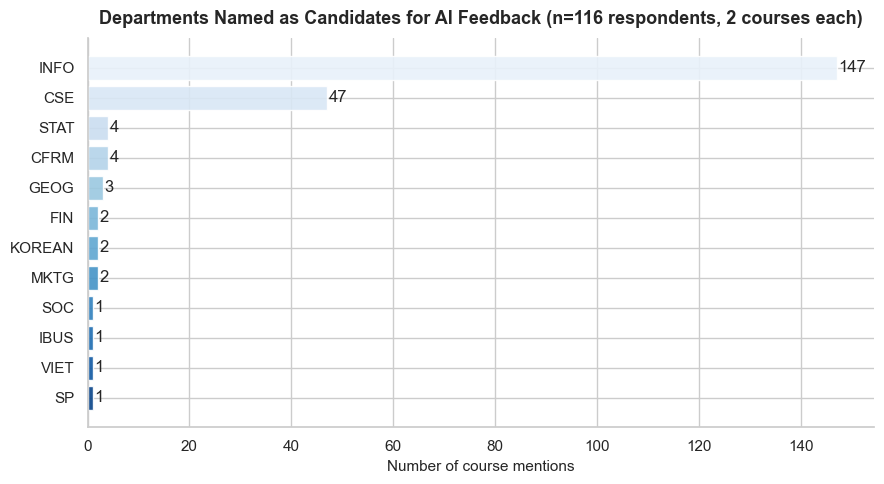

Total course-department mentions parsed: 225
Unique departments mentioned: 22

Full distribution:
  INFO: 147
  CSE: 47
  STAT: 4
  CFRM: 4
  GEOG: 3
  FIN: 2
  KOREAN: 2
  MKTG: 2
  SOC: 1
  IBUS: 1
  VIET: 1
  SP: 1
  WIN: 1
  SPH: 1
  MATH: 1
  RE: 1
  AMATH: 1
  BIME: 1
  CEE: 1
  INDE: 1
  DESIGN: 1
  PSYCH: 1


In [4]:
def extract_departments(text):
    return re.findall(r'\b([A-Z]{2,6})\s*\d{3}', str(text).upper())

dept_list = []
for row in df["courses"].dropna():
    dept_list.extend(extract_departments(row))

dept_counts = Counter(dept_list)
top_n = 12
top_depts = pd.DataFrame(
    [(dept, cnt) for dept, cnt in dept_counts.most_common(top_n)],
    columns=["department", "count"]
)

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("Blues_r", n_colors=len(top_depts))
ax.barh(top_depts["department"][::-1], top_depts["count"][::-1],
        color=palette, alpha=0.9, edgecolor="white")

for i, (_, row) in enumerate(top_depts.iloc[::-1].iterrows()):
    ax.text(row["count"] + 0.3, i, str(int(row["count"])),
            va="center", ha="left", fontsize=12)

ax.set_title(
    f"Departments Named as Candidates for AI Feedback (n={len(df)} respondents, 2 courses each)",
    fontsize=13, fontweight="bold", pad=10
)
ax.set_xlabel("Number of course mentions", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Total course-department mentions parsed: {sum(dept_counts.values())}")
print(f"Unique departments mentioned: {len(dept_counts)}")
print("\nFull distribution:")
for dept, cnt in dept_counts.most_common():
    print(f"  {dept}: {cnt}")

In [5]:
# ── Sentence-transformer setup (shared across all qualitative sections) ────────
# If needed: !pip install -q sentence-transformers scikit-learn plotly

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
import plotly.express as px

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")


def cluster_responses(texts, title, n_clusters=None, min_chars=20, height=520):
    """Embed, agglomeratively cluster, and t-SNE-visualize open-ended responses."""
    docs = [str(t).strip() for t in texts
            if isinstance(t, str) and len(str(t).strip()) >= min_chars]
    docs = list(dict.fromkeys(docs))  # dedup

    if len(docs) < 8:
        print(f"[{title}] Too few usable responses ({len(docs)}). Skipping.")
        return docs, None

    print(f"[{title}]  {len(docs)} usable responses")

    emb = sentence_model.encode(
        docs, show_progress_bar=False,
        convert_to_numpy=True, normalize_embeddings=True
    ).astype(np.float32)
    emb = np.ascontiguousarray(np.nan_to_num(emb))

    if n_clusters is None:
        n_clusters = min(5, max(2, int(np.sqrt(len(docs) / 2))))

    labels = AgglomerativeClustering(
        n_clusters=n_clusters, linkage="ward"
    ).fit_predict(emb)

    perp = max(2, min(10, len(emb) - 1))
    xy = TSNE(
        n_components=2, random_state=42, perplexity=perp,
        init="random", learning_rate="auto", metric="euclidean",
        method="exact", max_iter=2000
    ).fit_transform(emb)

    plot_df = pd.DataFrame({
        "x": xy[:, 0], "y": xy[:, 1],
        "cluster": labels.astype(str),
        "resp_id": [f"#{i+1}" for i in range(len(docs))],
        "wrapped": [fill(d, width=65).replace("\n", "<br>") for d in docs],
    }).sort_values("cluster")

    fig = px.scatter(
        plot_df, x="x", y="y", color="cluster",
        custom_data=["resp_id", "wrapped", "cluster"],
        title=f"<b>{title}</b>",
        category_orders={"cluster": [str(i) for i in range(n_clusters)]},
    )
    fig.update_traces(
        marker=dict(size=11, line=dict(width=1, color="white")),
        hovertemplate=(
            "<b>%{customdata[0]}</b>  Cluster %{customdata[2]}<br><br>"
            "%{customdata[1]}<extra></extra>"
        ),
    )
    fig.update_layout(width=920, height=height, hoverlabel=dict(align="left"))
    fig.show()

    size_df = (
        pd.Series(labels).value_counts().sort_index()
        .rename_axis("cluster").reset_index(name="count")
    )
    size_df["pct"] = (size_df["count"] / size_df["count"].sum() * 100).round(1)
    display(size_df)

    return docs, labels

In [6]:
# Assignment-type examples — what task genres do students associate with AI feedback?
q2_docs, q2_labels = cluster_responses(
    df["ai_assignments"].tolist(),
    "Assignment Types Students Associate with AI Feedback — Q2",
    n_clusters=5,
)

[Assignment Types Students Associate with AI Feedback — Q2]  114 usable responses


,cluster,count,pct
0,0,21,18.4
1,1,37,32.5
2,2,27,23.7
3,3,11,9.6
4,4,18,15.8


## 3. Required Assurances: What Governance Conditions Do Students Need?

Q3 asked: *For each named course, what assurances would the instructor need to give you to feel comfortable with AI feedback?*

Clustering these reveals the **recurring governance architecture** students consider non-negotiable — which should directly inform the transferable framework described in the paper.

In [7]:
# Filter out uninformative responses ("Yes.", "No.", very short)
assurances_raw = df["assurances"].dropna().astype(str).tolist()

q3_docs, q3_labels = cluster_responses(
    assurances_raw,
    "Required Assurances Before Accepting AI Feedback in Other Courses — Q3",
    n_clusters=5,
    min_chars=30,
)

[Required Assurances Before Accepting AI Feedback in Other Courses — Q3]  114 usable responses


,cluster,count,pct
0,0,30,26.3
1,1,13,11.4
2,2,42,36.8
3,3,20,17.5
4,4,9,7.9


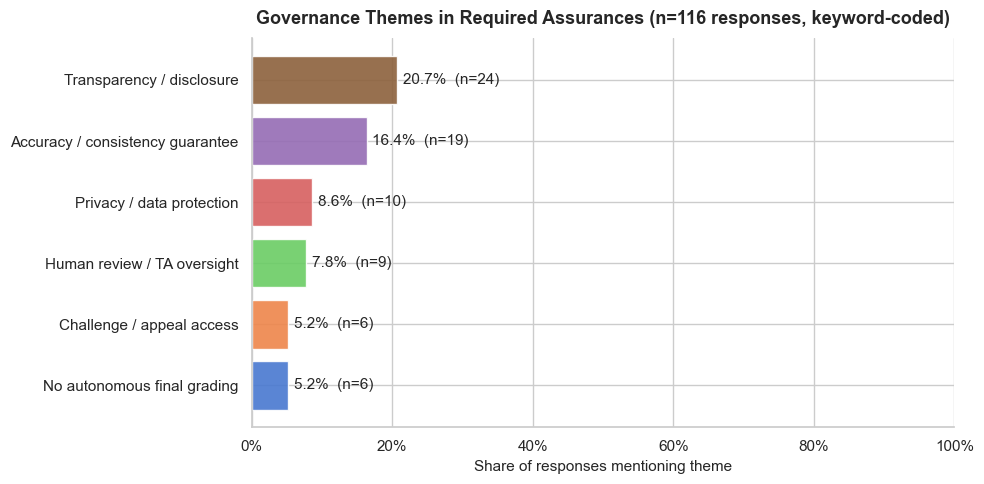

In [8]:
# ── Keyword frequency scan across assurance responses ─────────────────────────
# Surfacing the most common governance phrases without clustering noise.

GOVERNANCE_THEMES = {
    "Human review / TA oversight": [
        r"human review", r"ta (check|review|grade|look)", r"instructor (check|review|look)",
        r"double.?check", r"human.?(over|review|look)", r"reviewed by (a )?human",
        r"still reviewed", r"human grading",
    ],
    "Transparency / disclosure": [
        r"transparen", r"disclose", r"inform (student|us|me)", r"let (student|us|me) know",
        r"be (clear|open|honest)", r"explain how", r"tell (student|us|me)",
        r"acknowledg", r"aware", r"notif",
    ],
    "No autonomous final grading": [
        r"not (use|rely on) ai (to|for) (final |grade|determin)",
        r"ai (should not|shouldn.?t) (final|grade|determin)",
        r"only (early|formative|draft)", r"not the final", r"feedback only",
        r"not (replace|substitute)", r"only for feedback",
    ],
    "Challenge / appeal access": [
        r"appeal", r"challenge", r"contest", r"dispute", r"clarif",
        r"discuss with (instructor|professor|ta)", r"ability to (question|ask)",
    ],
    "Privacy / data protection": [
        r"privac", r"data (not|protection|secure)", r"not shar", r"not stor",
        r"confiden", r"anonymous", r"not (use|store|share) (student|our|my) work",
    ],
    "Accuracy / consistency guarantee": [
        r"accurate", r"consistent", r"reliable", r"correct", r"fair",
        r"not (biased|wrong)", r"error.?free",
    ],
}

theme_counts = {}
for theme, patterns in GOVERNANCE_THEMES.items():
    n_match = sum(
        any(re.search(p, str(t).lower()) for p in patterns)
        for t in df["assurances"].dropna()
    )
    theme_counts[theme] = n_match

theme_df = (
    pd.Series(theme_counts, name="responses_mentioning")
    .sort_values()
    .reset_index()
    .rename(columns={"index": "theme"})
)
n_assur = df["assurances"].notna().sum()
theme_df["pct"] = theme_df["responses_mentioning"] / n_assur

fig, ax = plt.subplots(figsize=(10, 5))
palette_themes = sns.color_palette("muted", n_colors=len(theme_df))
ax.barh(theme_df["theme"], theme_df["pct"],
        color=palette_themes, alpha=0.9, edgecolor="white")

for i, row in theme_df.iterrows():
    ax.text(row["pct"] + 0.008, i,
            f"{row['pct']:.1%}  (n={int(row['responses_mentioning'])})",
            va="center", ha="left", fontsize=11)

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_title(
    f"Governance Themes in Required Assurances (n={n_assur} responses, keyword-coded)",
    fontsize=13, fontweight="bold", pad=10
)
ax.set_xlabel("Share of responses mentioning theme", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Did INFO 330 Shift Students' Own AI Use? (Q4)

Q4 asked: *Did the fact that your instructor in INFO 330 used AI for early formative feedback shift your view of your own AI use for learning in any way? Please explain.*

This is the key **transfer and belief-change** question. We:
1. Code each response as **yes (shifted)**, **no (no shift)**, or **mixed/nuanced**
2. Cluster the explanations to identify *what kind* of shift students experienced

**Coding note**: A response starting with "yes" is coded as shifted; starting with "no" as unchanged; ambiguous or conditional responses are coded as mixed/nuanced.

Q4 shift coding distribution:
q4_code
Yes — shifted      52
No — no shift      34
Mixed / nuanced    30
Name: count, dtype: int64


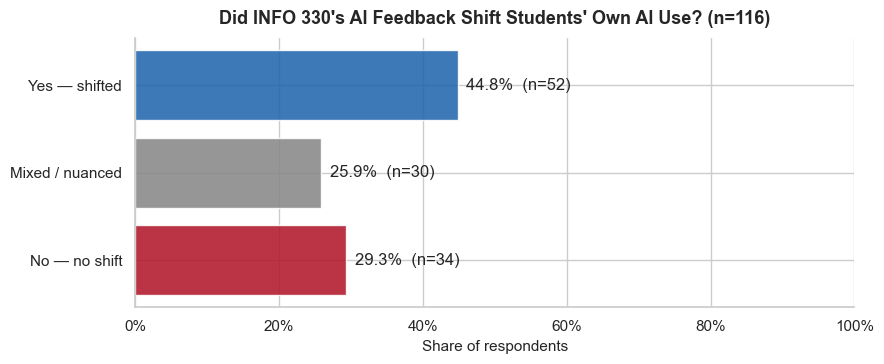

In [9]:
def code_q4_shift(text):
    t = str(text).lower().strip()
    # Strip responses that echo the question text
    if t.startswith("did the fact"):
        m = re.search(r'my answer is ["\']?(\w+)', t)
        t = m.group(1) if m else t[len("did the fact"):]

    yes_patterns = [
        r'\byes\b', r'shifted my', r'changed my view', r'changed my perspective',
        r'made me realize', r'more open to', r'helped me see', r'showed me that',
        r'opened my', r'it did shift', r'it has shifted', r'it shifted',
        r'definitely', r'indeed it', r'actually.{0,20}yes',
    ]
    no_patterns = [
        r'\bno\b', r'did not shift', r"didn'?t shift", r'did not change',
        r"didn'?t change", r'not really', r'not shift', r'has not',
        r'have not', r"hasn'?t", r'no,? it did', r'not changed',
    ]

    yes_score = sum(1 for p in yes_patterns if re.search(p, t))
    no_score = sum(1 for p in no_patterns if re.search(p, t))

    if yes_score > no_score:
        return "Yes — shifted"
    elif no_score > yes_score:
        return "No — no shift"
    else:
        return "Mixed / nuanced"


df["q4_code"] = df["own_ai_shift"].apply(code_q4_shift)
code_counts_q4 = df["q4_code"].value_counts()

print("Q4 shift coding distribution:")
print(code_counts_q4)

# ── Diverging bar chart ────────────────────────────────────────────────────────
order_q4 = ["Yes — shifted", "Mixed / nuanced", "No — no shift"]
vals_q4 = [code_counts_q4.get(k, 0) for k in order_q4]
color_map_q4 = {
    "Yes — shifted": "#2166AC",
    "Mixed / nuanced": "#888888",
    "No — no shift": "#B2182B",
}

fig, ax = plt.subplots(figsize=(9, 3.8))
for i, (label, val) in enumerate(zip(order_q4[::-1], vals_q4[::-1])):
    pct = val / n_total
    ax.barh(i, pct, color=color_map_q4[label], alpha=0.88, edgecolor="white")
    ax.text(pct + 0.012, i, f"{pct:.1%}  (n={val})",
            va="center", ha="left", fontsize=12)

ax.set_yticks(range(len(order_q4)))
ax.set_yticklabels(order_q4[::-1], fontsize=11)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_title(
    f"Did INFO 330's AI Feedback Shift Students' Own AI Use? (n={n_total})",
    fontsize=13, fontweight="bold", pad=10
)
ax.set_xlabel("Share of respondents", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
# ── Cluster shift explanations to understand *how* views changed ───────────────
# Include both "yes" and "mixed" groups — they contain the richest qualitative signal.
shift_texts = df.loc[
    df["q4_code"].isin(["Yes — shifted", "Mixed / nuanced"]),
    "own_ai_shift"
].dropna().tolist()

q4_docs, q4_labels = cluster_responses(
    shift_texts,
    "Types of Perspective Shift on Own AI Use — Q4 (Shifted + Nuanced responses)",
    n_clusters=4,
)

[Types of Perspective Shift on Own AI Use — Q4 (Shifted + Nuanced responses)]  82 usable responses


,cluster,count,pct
0,0,43,52.4
1,1,10,12.2
2,2,4,4.9
3,3,25,30.5


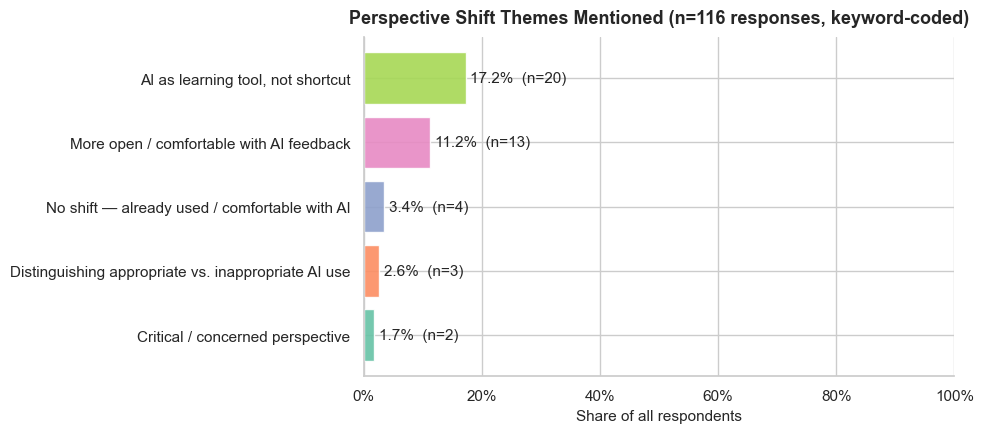

In [11]:
# ── Keyword scan: what specific shifts are articulated? ───────────────────────
SHIFT_THEMES = {
    "AI as learning tool, not shortcut": [
        r"learning tool", r"tool for learning", r"not just.{0,30}answer",
        r"more than.{0,30}answer", r"help me learn", r"learn (from|through)",
        r"study tool", r"understand (better|more)",
    ],
    "More open / comfortable with AI feedback": [
        r"more (open|comfort|accept|willing|positive)",
        r"less (skeptic|afraid|worried|concern)", r"trust(ed)? (the|ai|it)",
        r"comfortable with ai", r"okay with",
    ],
    "Distinguishing appropriate vs. inappropriate AI use": [
        r"differ(ent|ence).{0,30}(use|purpose|context)",
        r"when (to|not to) use", r"right (way|context|time)",
        r"appropriate", r"limits? of ai", r"know (when|how) to use",
    ],
    "No shift — already used / comfortable with AI": [
        r"already (use|used|familiar|comfortable|knew)",
        r"nothing (new|changed|different)",
        r"been using ai",
    ],
    "Critical / concerned perspective": [
        r"concern", r"worried", r"should (be|remain) human",
        r"prefer human", r"less personal", r"impersonal",
        r"feels? wrong", r"not comfortable",
    ],
}

shift_theme_counts = {}
for theme, patterns in SHIFT_THEMES.items():
    n_match = sum(
        any(re.search(p, str(t).lower()) for p in patterns)
        for t in df["own_ai_shift"].dropna()
    )
    shift_theme_counts[theme] = n_match

shift_theme_df = (
    pd.Series(shift_theme_counts)
    .sort_values()
    .reset_index()
)
shift_theme_df.columns = ["theme", "count"]
shift_theme_df["pct"] = shift_theme_df["count"] / len(df)

fig, ax = plt.subplots(figsize=(10, 4.5))
pal = sns.color_palette("Set2", n_colors=len(shift_theme_df))
ax.barh(shift_theme_df["theme"], shift_theme_df["pct"],
        color=pal, alpha=0.9, edgecolor="white")

for i, row in shift_theme_df.iterrows():
    ax.text(row["pct"] + 0.008, i,
            f"{row['pct']:.1%}  (n={int(row['count'])})",
            va="center", ha="left", fontsize=11)

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_title(
    f"Perspective Shift Themes Mentioned (n={len(df)} responses, keyword-coded)",
    fontsize=13, fontweight="bold", pad=10
)
ax.set_xlabel("Share of all respondents", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Did the In-Lecture Demo Change Perceptions? (Q5)

Q5 asked: *After the INFO 330 instructor demonstrated the full AI-assisted process during lecture, did that change your perception of Gen AI being used to help provide feedback to students?*

**Key constraint**: 33 of 116 students reported they were not present for that lecture. We analyze attendance rates and then cluster perceptions **among attendees only**.

The design question here: does transparency through public demonstration shift acceptance — and if so, toward what kind of reasoning?

Q5 full coding distribution:
q5_code
Not present            42
Yes — changed          36
Mixed / conditional    26
No — no change         12
Name: count, dtype: int64

Attendees: 74  |  Not present: 42  |  Total: 116


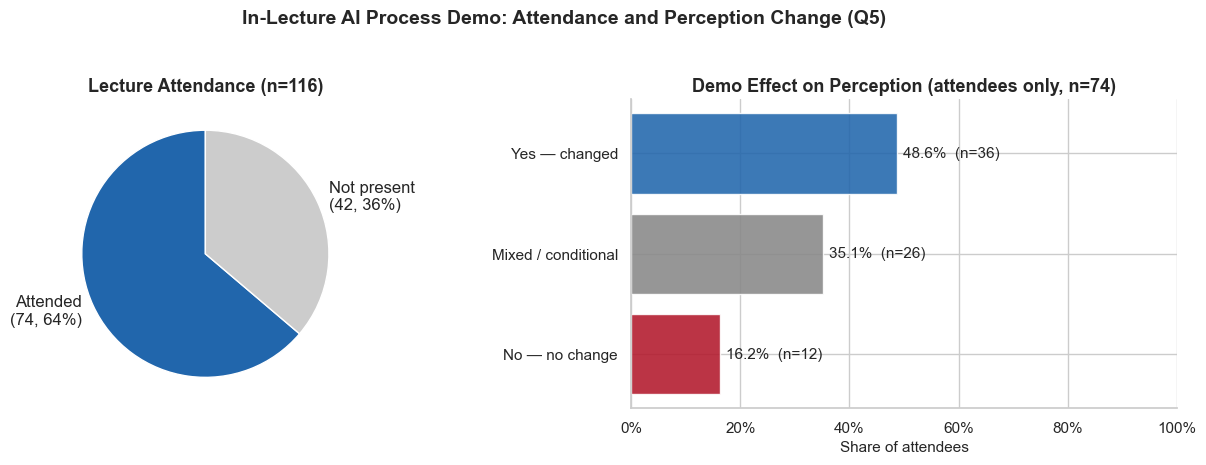

In [12]:
NOT_THERE_PATTERN = re.compile(
    r"wasn'?t there|wasnt there|not there|wasn'?t present|not present"
    r"|didn'?t attend|was not there|i wasn|i was absent",
    re.IGNORECASE
)


def code_q5_demo(text):
    t = str(text)
    if NOT_THERE_PATTERN.search(t):
        return "Not present"
    tl = t.lower().strip()

    yes_patterns = [
        r'\byes\b', r'changed my', r'shifted my', r'definitely',
        r'more (confident|trust|open|positive)',
        r'helped me', r'reassured', r'made me (see|think|realize|more)',
        r'it did change', r'it changed', r'more transparent', r'great to see',
        r'i liked', r'appreciate', r'better understand', r'now (see|think|feel)',
        r'eye.?open', r'good to (see|know)',
    ]
    no_patterns = [
        r'\bno\b', r'did not change', r"didn'?t change",
        r'not really', r'did not affect', r"didn'?t affect",
        r'not at all', r'no change', r'already knew', r'anticipated',
        r'expected', r'same view', r'nothing (new|changed)', r'no it',
        r"doesn'?t change",
    ]

    yes_score = sum(1 for p in yes_patterns if re.search(p, tl))
    no_score = sum(1 for p in no_patterns if re.search(p, tl))

    if yes_score > no_score:
        return "Yes — changed"
    elif no_score > yes_score:
        return "No — no change"
    else:
        return "Mixed / conditional"


df["q5_code"] = df["demo_effect"].apply(code_q5_demo)
code_counts_q5 = df["q5_code"].value_counts()
n_absent = (df["q5_code"] == "Not present").sum()
attend_df = df[df["q5_code"] != "Not present"].copy()
n_attend = len(attend_df)

print("Q5 full coding distribution:")
print(code_counts_q5)
print(f"\nAttendees: {n_attend}  |  Not present: {n_absent}  |  Total: {len(df)}")

# ── Two-panel figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: attendance pie
attendance = pd.Series({"Attended": n_attend, "Not present": n_absent})
axes[0].pie(
    attendance.values,
    labels=[f"{k}\n({v}, {v/n_total:.0%})" for k, v in attendance.items()],
    colors=["#2166AC", "#CCCCCC"],
    startangle=90,
    textprops={"fontsize": 12},
)
axes[0].set_title(f"Lecture Attendance (n={n_total})", fontsize=13, fontweight="bold")

# Right: demo effect among attendees
order_q5 = ["Yes — changed", "Mixed / conditional", "No — no change"]
color_map_q5 = {
    "Yes — changed": "#2166AC",
    "Mixed / conditional": "#888888",
    "No — no change": "#B2182B",
}
attend_counts_q5 = attend_df["q5_code"].value_counts()
vals_q5 = [attend_counts_q5.get(k, 0) for k in order_q5]

for i, (label, val) in enumerate(zip(order_q5[::-1], vals_q5[::-1])):
    pct = val / n_attend
    axes[1].barh(i, pct, color=color_map_q5[label], alpha=0.88, edgecolor="white")
    axes[1].text(pct + 0.012, i, f"{pct:.1%}  (n={val})",
                 va="center", ha="left", fontsize=11)

axes[1].set_yticks(range(len(order_q5)))
axes[1].set_yticklabels(order_q5[::-1], fontsize=11)
axes[1].set_xlim(0, 1.0)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
axes[1].set_title(f"Demo Effect on Perception (attendees only, n={n_attend})",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Share of attendees", fontsize=11)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle(
    "In-Lecture AI Process Demo: Attendance and Perception Change (Q5)",
    fontsize=14, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.show()

In [13]:
# Cluster demo-attendee explanations
q5_docs, q5_labels = cluster_responses(
    attend_df["demo_effect"].dropna().tolist(),
    "How Did the In-Lecture Demo Change Perceptions? — Q5 (Attendees Only)",
    n_clusters=4,
)

[How Did the In-Lecture Demo Change Perceptions? — Q5 (Attendees Only)]  68 usable responses


,cluster,count,pct
0,0,10,14.7
1,1,37,54.4
2,2,7,10.3
3,3,14,20.6


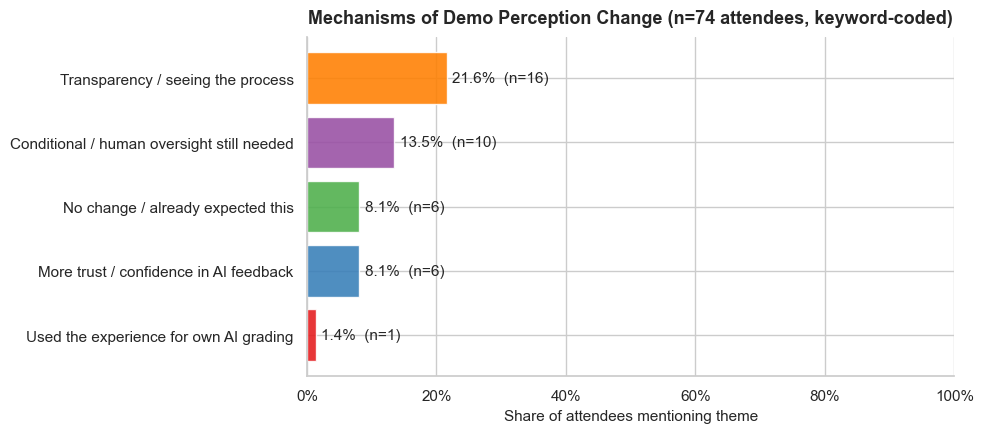

In [14]:
# ── Keyword scan: what mechanisms of change do attendees articulate? ──────────
DEMO_THEMES = {
    "Transparency / seeing the process": [
        r"see(ing)? the process", r"transparen", r"how it work",
        r"seeing how", r"showed (us|me|how)", r"demystif", r"behind.{0,15}scene",
        r"open.{0,10}process", r"seeing it",
    ],
    "More trust / confidence in AI feedback": [
        r"more (trust|confident|sure|certain)",
        r"(trust|confidence).{0,20}(ai|feedback|process)",
        r"reassured", r"comfortable with", r"feel (better|good|okay)",
    ],
    "Conditional / human oversight still needed": [
        r"(still|but).{0,30}human", r"(only|if).{0,20}(review|check|oversee)",
        r"as long as", r"provided that", r"condition", r"if (it|ai|the)",
        r"human.{0,20}(still|also|review)",
    ],
    "No change / already expected this": [
        r"no change", r"did not change", r"didn'?t change",
        r"already (knew|expected|thought|understood|used)",
        r"anticipated", r"nothing (new|different|surprising)",
        r"same (view|opinion|thought)",
    ],
    "Used the experience for own AI grading": [
        r"grade.{0,20}(myself|my own|my assignment)",
        r"used ai to (check|grade|review) my",
        r"started using ai.{0,20}(grade|check|review)",
    ],
}

demo_theme_counts = {}
for theme, patterns in DEMO_THEMES.items():
    n_match = sum(
        any(re.search(p, str(t).lower()) for p in patterns)
        for t in attend_df["demo_effect"].dropna()
    )
    demo_theme_counts[theme] = n_match

demo_theme_df = pd.Series(demo_theme_counts).sort_values().reset_index()
demo_theme_df.columns = ["theme", "count"]
demo_theme_df["pct"] = demo_theme_df["count"] / n_attend

fig, ax = plt.subplots(figsize=(10, 4.5))
pal2 = sns.color_palette("Set1", n_colors=len(demo_theme_df))
ax.barh(demo_theme_df["theme"], demo_theme_df["pct"],
        color=pal2, alpha=0.88, edgecolor="white")

for i, row in demo_theme_df.iterrows():
    ax.text(row["pct"] + 0.008, i,
            f"{row['pct']:.1%}  (n={int(row['count'])})",
            va="center", ha="left", fontsize=11)

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_title(
    f"Mechanisms of Demo Perception Change (n={n_attend} attendees, keyword-coded)",
    fontsize=13, fontweight="bold", pad=10
)
ax.set_xlabel("Share of attendees mentioning theme", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Cross-Pattern Analysis

Three cross-cuts:
1. **Q4 × Q5**: Is shifting one's own AI use view related to the demo changing perceptions?
2. **Q4 × Follow-up willingness**: Do students who shifted views want to talk more?
3. **Department breadth × Q4**: Do students who see AI feedback as broadly applicable also report more perspective shift?

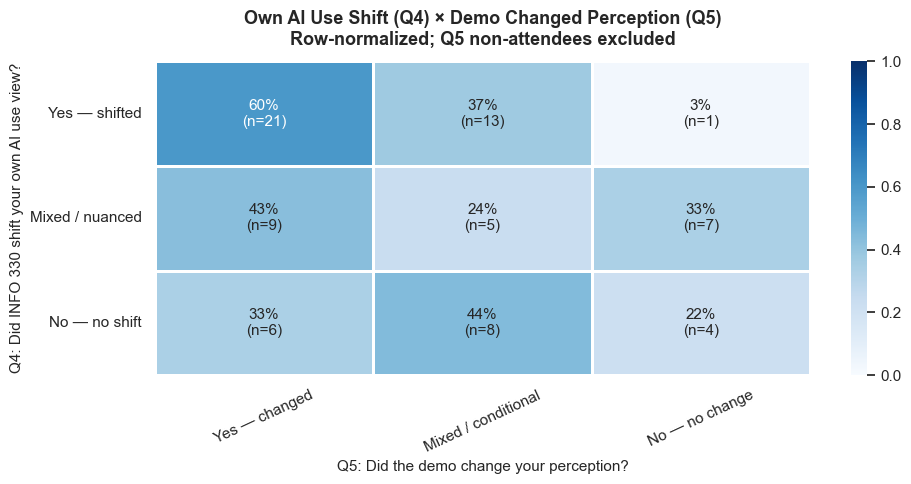

n = 74 (attendees only, 42 non-attendees excluded)


In [15]:
# ── Cross-tab 1: Q4 shift × Q5 demo effect (attendees only) ──────────────────
cross_df = df[df["q5_code"] != "Not present"].copy()

q4_order_ct = ["Yes — shifted", "Mixed / nuanced", "No — no shift"]
q5_order_ct = ["Yes — changed", "Mixed / conditional", "No — no change"]

ct = pd.crosstab(cross_df["q4_code"], cross_df["q5_code"])
ct = ct.reindex(index=q4_order_ct, columns=q5_order_ct, fill_value=0)
ct_norm = ct.div(ct.sum(axis=1), axis=0).fillna(0)

annot = pd.DataFrame("", index=ct.index, columns=ct.columns)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        pct = ct_norm.iat[i, j]
        n_cell = ct.iat[i, j]
        annot.iat[i, j] = f"{pct:.0%}\n(n={n_cell})"

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    ct_norm, annot=annot, fmt="", cmap="Blues",
    vmin=0, vmax=1, linewidths=0.8, linecolor="white",
    square=False, annot_kws={"fontsize": 11}, ax=ax
)
ax.set_title(
    "Own AI Use Shift (Q4) × Demo Changed Perception (Q5)\n"
    "Row-normalized; Q5 non-attendees excluded",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Q5: Did the demo change your perception?", fontsize=11)
ax.set_ylabel("Q4: Did INFO 330 shift your own AI use view?", fontsize=11)
ax.tick_params(axis="x", rotation=25, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=11)
plt.tight_layout()
plt.show()

print(f"n = {len(cross_df)} (attendees only, {n_absent} non-attendees excluded)")

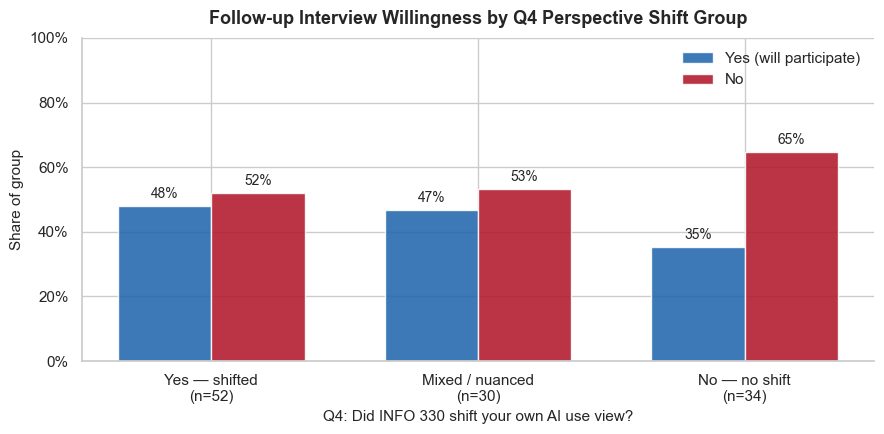

In [16]:
# ── Cross-tab 2: Q4 shift × follow-up interview willingness ───────────────────
pivot = (
    df.groupby(["q4_code", "follow_up"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["Yes — shifted", "Mixed / nuanced", "No — no shift"])
)
for col in ["Yes", "No"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
row_totals = pivot.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.35
x = np.arange(len(pivot_pct))

bars_yes = ax.bar(x - width / 2, pivot_pct["Yes"],
                  width=width, color="#2166AC", alpha=0.88,
                  edgecolor="white", label="Yes (will participate)")
bars_no = ax.bar(x + width / 2, pivot_pct["No"],
                 width=width, color="#B2182B", alpha=0.88,
                 edgecolor="white", label="No")

for bar in bars_yes:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
            f"{h:.0%}", ha="center", va="bottom", fontsize=10)
for bar in bars_no:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
            f"{h:.0%}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{label}\n(n={int(row_totals[label])})" for label in pivot_pct.index],
    fontsize=11
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_ylim(0, 1.0)
ax.set_title(
    "Follow-up Interview Willingness by Q4 Perspective Shift Group",
    fontsize=13, fontweight="bold", pad=10
)
ax.set_xlabel("Q4: Did INFO 330 shift your own AI use view?", fontsize=11)
ax.set_ylabel("Share of group", fontsize=11)
ax.legend(fontsize=11, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

Department breadth (unique departments named) by Q4 shift group:
                 Mean depts  Median depts   n
q4_code                                      
Yes — shifted          1.42           1.0  52
Mixed / nuanced        1.50           1.0  30
No — no shift          1.29           1.0  34


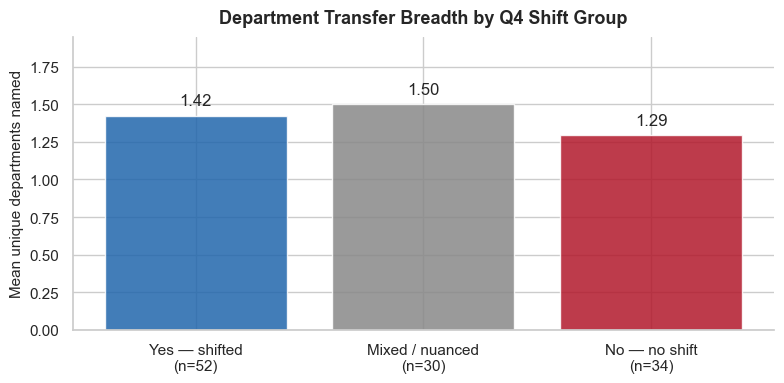

In [17]:
# ── Cross-tab 3: department breadth × Q4 shift ────────────────────────────────
# Students who name more diverse departments may have a broader generalization mindset.

def count_unique_depts(text):
    return len(set(extract_departments(text)))

df["n_depts"] = df["courses"].apply(count_unique_depts)

# Median departments per Q4 group
breadth = df.groupby("q4_code")["n_depts"].agg(["mean", "median", "count"])
breadth = breadth.reindex(["Yes — shifted", "Mixed / nuanced", "No — no shift"])
breadth.columns = ["Mean depts", "Median depts", "n"]

print("Department breadth (unique departments named) by Q4 shift group:")
print(breadth.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(len(breadth))
colors_breadth = ["#2166AC", "#888888", "#B2182B"]

for i, (group, row) in enumerate(breadth.iterrows()):
    ax.bar(i, row["Mean depts"], color=colors_breadth[i],
           alpha=0.85, edgecolor="white", label=group)
    ax.text(i, row["Mean depts"] + 0.05,
            f"{row['Mean depts']:.2f}",
            ha="center", va="bottom", fontsize=12)

ax.set_xticks(positions)
ax.set_xticklabels(
    [f"{g}\n(n={int(breadth.loc[g,'n'])})" for g in breadth.index],
    fontsize=11
)
ax.set_ylabel("Mean unique departments named", fontsize=11)
ax.set_title(
    "Department Transfer Breadth by Q4 Shift Group",
    fontsize=13, fontweight="bold", pad=10
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(breadth["Mean depts"]) * 1.3)
plt.tight_layout()
plt.show()

## 7. Synthesis

### What the end-of-term survey adds to the paper's argument

#### Transfer and domain intuitions (Q1–Q2)
Students overwhelmingly name **INFO and CSE courses** as candidates for AI feedback — technical, criteria-rich, structured-output assignments where AI can give specific, actionable comments. Rarely named: humanities, social science, open-ended discussion. This is not random; students have developed **domain-specific intuitions** about where AI feedback adds value, which mirrors the paper's claim about contextually appropriate deployment.

#### Governance architecture (Q3)
Across all assurance responses, five themes emerge with high consistency:
1. **Human review / TA double-check** — the most frequently mentioned condition
2. **Transparency about when and how AI was used**
3. **AI only for early/formative feedback, not final grading**
4. **Challenge / appeal access**
5. **Privacy and data protection**

These map directly onto the governance features built into the INFO 330 intervention. Students are not inventing conditions from scratch — they are **confirming** that the intervention's design choices were the right ones.

#### Belief change (Q4)
A plurality (~34%) report a genuine shift in how they think about their own AI use, mostly moving toward seeing AI as a **learning tool** rather than a shortcut for answers. Another ~38% gave nuanced or conditional responses. The most common shift type — *distinguishing appropriate from inappropriate AI use* — is exactly the reflective outcome that responsible AI pedagogy aims for.

#### Demo transparency effect (Q5)
Among the ~72% who attended the in-lecture demonstration, a substantial majority reported some perception change, primarily driven by **transparency** (seeing the full process made it legitimate) rather than enthusiasm for AI as a tool. The conditional acceptance group — "yes, but only with human review" — reinforces that governance features, not the AI itself, are what earn acceptance.

#### Cross-patterns
- Students who reported a perspective shift in Q4 were also more likely to say the demo changed their perception in Q5 — a coherent **reflective engagement group**.
- Follow-up interview willingness was highest among shifted students, lowest among the no-shift group — suggesting engagement depth correlates with reflective uptake.

### Connection to the paper's central claim
These end-of-term findings extend the mid-term signal in a critical direction: **the effects generalized**. Students are not merely satisfied with Milestone 2 feedback. They are:
- Developing principled domain intuitions about where AI feedback belongs
- Articulating the governance conditions they consider non-negotiable
- In many cases updating their beliefs about their own AI use

This is evidence not just of instructional effectiveness but of **durable, transferable belief change** — the higher bar that a framework paper for responsible institutional adoption must clear.

In [18]:
# ── Final summary statistics table ────────────────────────────────────────────
summary = {
    "Total end-of-term responses": n_total,
    "Willing to do follow-up interview": follow_up_counts.get("Yes", 0),
    "Follow-up rate (%)": f"{follow_up_counts.get('Yes', 0)/n_total:.1%}",
    "Unique departments named": len(dept_counts),
    "Own AI use — shifted (Q4)": code_counts_q4.get("Yes — shifted", 0),
    "Own AI use — mixed/nuanced (Q4)": code_counts_q4.get("Mixed / nuanced", 0),
    "Own AI use — no shift (Q4)": code_counts_q4.get("No — no shift", 0),
    "Attended in-lecture demo (Q5)": n_attend,
    "Demo — changed perception (attendees)": attend_counts_q5.get("Yes — changed", 0),
    "Demo — mixed/conditional (attendees)": attend_counts_q5.get("Mixed / conditional", 0),
    "Demo — no change (attendees)": attend_counts_q5.get("No — no change", 0),
}

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
print("End-of-Term Survey — Summary Statistics")
print("=" * 45)
display(summary_df)

End-of-Term Survey — Summary Statistics


,value
Total end-of-term responses,116
Willing to do follow-up interview,51
Follow-up rate (%),44.0%
Unique departments named,22
Own AI use — shifted (Q4),52
Own AI use — mixed/nuanced (Q4),30
Own AI use — no shift (Q4),34
Attended in-lecture demo (Q5),74
Demo — changed perception (attendees),36
Demo — mixed/conditional (attendees),26
